In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("50_Startups.csv")
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,78013.11,121597.55,264346.06,Tamilnadu,126992.93
1,86419.70,153514.11,293917.57,Bangalore,122776.86
2,91992.39,135495.07,252664.93,Kerala,134307.35
3,93863.75,127320.38,249839.44,Tamilnadu,141585.52
4,94657.16,145077.58,282574.31,Kerala,125370.37
5,100671.96,91790.61,249744.55,Bangalore,144259.40
6,114523.61,122616.84,261776.23,Bangalore,129917.04
7,120542.52,148718.95,311613.29,Tamilnadu,152211.77
8,123334.88,108679.17,304981.62,Kerala,149759.96
9,130298.13,145530.06,323876.68,Bangalore,155752.60


In [3]:
dataset=pd.get_dummies(dataset,drop_first=True)
dataset=dataset.astype(int)
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Kerala,State_Tamilnadu
0,78013,121597,264346,126992,0,1
1,86419,153514,293917,122776,0,0
2,91992,135495,252664,134307,1,0
3,93863,127320,249839,141585,0,1
4,94657,145077,282574,125370,1,0
5,100671,91790,249744,144259,0,0
6,114523,122616,261776,129917,0,0
7,120542,148718,311613,152211,0,1
8,123334,108679,304981,149759,1,0
9,130298,145530,323876,155752,0,0


In [4]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Kerala', 'State_Tamilnadu'],
      dtype='object')

In [5]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend',
       'State_Kerala', 'State_Tamilnadu']]
independent

,R&D Spend,Administration,Marketing Spend,State_Kerala,State_Tamilnadu
0,78013,121597,264346,0,1
1,86419,153514,293917,0,0
2,91992,135495,252664,1,0
3,93863,127320,249839,0,1
4,94657,145077,282574,1,0
5,100671,91790,249744,0,0
6,114523,122616,261776,0,0
7,120542,148718,311613,0,1
8,123334,108679,304981,1,0
9,130298,145530,323876,0,0


In [6]:
dependent=dataset[['Profit']]
dependent

,Profit
0,126992
1,122776
2,134307
3,141585
4,125370
5,144259
6,129917
7,152211
8,149759
9,155752


In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(independent, dependent, test_size=0.20, random_state=0)

In [34]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='friedman_mse', max_depth=3)
regressor.fit(x_train, y_train)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


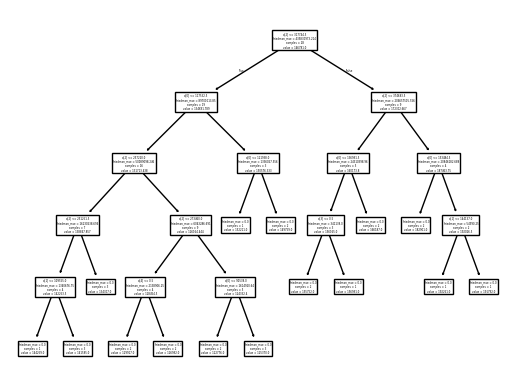

In [26]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [35]:
y_pred=regressor.predict(x_test)

In [36]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test, y_pred)

In [37]:
r_score

0.9909961611205617

In [20]:
import pickle
filename="finalized_model_DecisionTreeRegressor.sav"
pickle.dump(regressor,open(filename,'wb'))

In [22]:
loaded_model=pickle.load(open("finalized_model_DecisionTreeRegressor.sav",'rb'))
result=loaded_model.predict([[2345,123,5656,0,1]])

C:\Users\KRISHNABALAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [23]:
result

array([141585.])

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(independent, dependent, test_size=0.20, random_state=0)

In [40]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='friedman_mse', min_samples_split=2)
regressor.fit(x_train, y_train)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


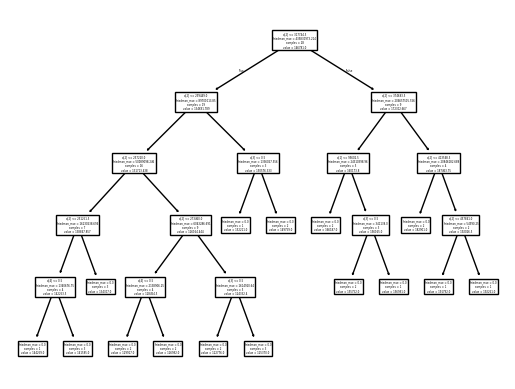

In [41]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [42]:
y_pred=regressor.predict(x_test)
from sklearn.metrics import r2_score
r_score=r2_score(y_test, y_pred)
r_score

1.0

In [43]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(independent, dependent, test_size=0.20, random_state=0)
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='friedman_mse', min_samples_leaf=1)
regressor.fit(x_train, y_train)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


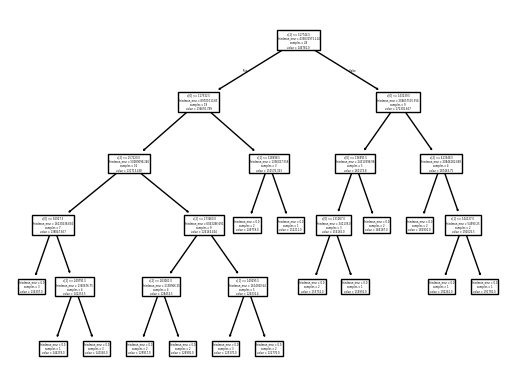

In [44]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [45]:
y_pred=regressor.predict(x_test)
from sklearn.metrics import r2_score
r_score=r2_score(y_test, y_pred)
r_score

1.0